In [1]:
# LOAD DATA

import pandas as pd

df = pd.read_csv("../data/interim/healtcare_processedv2.csv")

# BASIC CHECK
print("Columns:", df.columns)
print("Shape:", df.shape)

df['patient_hash'] = df['Age'].astype(str) + '_' + df['Gender'].astype(str) + '_' + df['Blood Type'].astype(str)
df['patient_id'] = df.groupby('patient_hash').ngroup()
df = df.drop(columns=['patient_hash'])

df["condition_id"] = df["Medical Condition"].astype("category").cat.codes
df["medication_id"] = df["Medication"].astype("category").cat.codes

# CREATE TABLES

patients = df[["patient_id", "Age", "Gender", "Blood Type"]].drop_duplicates()

# 'Hospital' and 'Doctor' columns are not available, so hospitals and doctors tables cannot be created.
# hospitals = df[["hospital_id", "Hospital"]].drop_duplicates()
# doctors = df[["doctor_id", "Doctor"]].drop_duplicates()

medical_conditions = df[["condition_id", "Medical Condition"]].drop_duplicates()

medications = df[["medication_id", "Medication"]].drop_duplicates()

df["record_id"] = range(len(df))

medical_records = df[[
    "record_id",
    "patient_id",
    # "hospital_id", # Removed as 'Hospital' column is not available
    # "doctor_id", # Removed as 'Doctor' column is not available
    "condition_id",
    "medication_id",
    "Admission Type",
    "Billing Amount",
    "Test Results",
    "Length of Stay"
]]



Columns: Index(['Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication',
       'Test Results', 'Length of Stay', 'Admission Day of Week',
       'Admission Month', 'Admission Year'],
      dtype='str')
Shape: (54966, 13)


### Creación de Matrices de Características (Feature Matrices)

Una matriz de características es una tabla donde cada fila representa una instancia (por ejemplo, un paciente, un hospital) y cada columna representa una característica o atributo de esa instancia. Estas matrices son fundamentales para el aprendizaje automático.

A continuación, generaremos una matriz de características para los **pacientes**, combinando sus datos demográficos con estadísticas agregadas de sus registros médicos.

In [2]:
# Para crear una matriz de características de pacientes, primero uniremos la información demográfica de los pacientes con sus registros médicos.
# Luego, podemos agregar características relevantes por paciente.

# Unir `patients` con `medical_records`
patient_medical_data = pd.merge(
    patients,
    medical_records,
    on='patient_id',
    how='left'
)

# Ejemplo: Agregamos algunas características para cada paciente
patient_feature_matrix = patient_medical_data.groupby('patient_id').agg(
    age=('Age', 'first'),
    gender=('Gender', 'first'),
    blood_type=('Blood Type', 'first'),
    total_admissions=('record_id', 'count'),
    avg_billing_amount=('Billing Amount', 'mean'),
    avg_length_of_stay=('Length of Stay', 'mean')
).reset_index()

print("Matriz de Características de Pacientes (Primeras 5 filas):")
display(patient_feature_matrix.head())

print(f"\nDimensiones de la Matriz de Características de Pacientes: {patient_feature_matrix.shape}")

Matriz de Características de Pacientes (Primeras 5 filas):


,patient_id,age,gender,blood_type,total_admissions,avg_billing_amount,avg_length_of_stay
0,0,13,0,0,1,42349.109219,17.0
1,1,13,0,2,1,30506.935724,26.0
2,2,13,0,5,2,31031.952325,19.5
3,3,13,0,7,1,22316.169323,23.0
4,4,13,1,0,2,6805.974826,29.5



Dimensiones de la Matriz de Características de Pacientes: (1196, 7)


### Ampliación de la Matriz de Características del Paciente

Continuaremos ampliando la matriz de características del paciente con:

1.  **Codificación One-Hot** para las variables categóricas 'Gender' y 'Blood Type'.
2.  **Estadísticas de Condiciones Médicas**: Conteo de cada condición y la condición más frecuente por paciente.
3.  **Estadísticas de Medicamentos**: Conteo de cada medicamento y el medicamento más frecuente por paciente.
4.  **Estadísticas de Resultados de Pruebas**: Proporción de resultados 'Normal' y 'Abnormal' por paciente.

In [3]:
# The 'Medical Condition' and 'Medication' columns in medical_conditions and medications
# are numerical IDs themselves, not descriptive names. Therefore, merging them here
# to get "names" is not necessary and may cause issues if the column names clash or are missing.
# We will use 'condition_id' and 'medication_id' directly which are already in patient_medical_data.

# Re-initialize patient_feature_matrix to its base state to avoid duplicate columns upon re-execution.
patient_feature_matrix = patient_medical_data.groupby('patient_id').agg(
    age=('Age', 'first'),
    gender=('Gender', 'first'),
    blood_type=('Blood Type', 'first'),
    total_admissions=('record_id', 'count'),
    avg_billing_amount=('Billing Amount', 'mean'),
    avg_length_of_stay=('Length of Stay', 'mean')
).reset_index()

# 1. Codificación One-Hot para 'Gender' y 'Blood Type'
# Usamos el dataframe original `patients` para evitar duplicación de filas en `patient_medical_data`
patient_demographics_encoded = pd.get_dummies(patients, columns=['Gender', 'Blood Type'], prefix=['Gender', 'BloodType'])
patient_demographics_encoded = patient_demographics_encoded.drop(columns=['Age'])

# Drop the original 'gender' and 'blood_type' columns from patient_feature_matrix
# as they will be replaced by the one-hot encoded versions.
patient_feature_matrix = patient_feature_matrix.drop(columns=['gender', 'blood_type'])

# Unir las características demográficas codificadas al patient_feature_matrix
patient_feature_matrix = pd.merge(
    patient_feature_matrix,
    patient_demographics_encoded,
    on='patient_id',
    how='left'
)

# 2. Estadísticas de Condiciones Médicas por Paciente
condition_counts = patient_medical_data.groupby('patient_id')['condition_id'].value_counts().unstack(fill_value=0)
# Convert column names to string before applying lower()
condition_counts.columns = [f'condition_{str(col).lower().replace(" ", "_")}_count' for col in condition_counts.columns]

most_frequent_condition = patient_medical_data.groupby('patient_id')['condition_id'].agg(lambda x: x.mode()[0] if not x.mode().empty else None).reset_index()
most_frequent_condition.rename(columns={'condition_id': 'most_frequent_condition_id'}, inplace=True)

# 3. Estadísticas de Medicamentos por Paciente
medication_counts = patient_medical_data.groupby('patient_id')['medication_id'].value_counts().unstack(fill_value=0)
# Convert column names to string before applying lower()
medication_counts.columns = [f'medication_{str(col).lower().replace(" ", "_")}_count' for col in medication_counts.columns]

most_frequent_medication = patient_medical_data.groupby('patient_id')['medication_id'].agg(lambda x: x.mode()[0] if not x.mode().empty else None).reset_index()
most_frequent_medication.rename(columns={'medication_id': 'most_frequent_medication_id'}, inplace=True)

# 4. Estadísticas de Resultados de Pruebas por Paciente
test_results_counts = patient_medical_data.groupby('patient_id')['Test Results'].value_counts(normalize=True).unstack(fill_value=0)
# Convert column names to string before applying lower()
test_results_counts.columns = [f'test_result_{str(col).lower().replace(" ", "_")}_prop' for col in test_results_counts.columns]

# Unir todas las nuevas características a la matriz principal
patient_feature_matrix = pd.merge(patient_feature_matrix, condition_counts, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, most_frequent_condition, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, medication_counts, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, most_frequent_medication, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, test_results_counts, on='patient_id', how='left')

print("Matriz de Características de Pacientes ampliada (Primeras 5 filas):")
display(patient_feature_matrix.head())
print(f"\nDimensiones de la Matriz de Características de Pacientes ampliada: {patient_feature_matrix.shape}")

Matriz de Características de Pacientes ampliada (Primeras 5 filas):


,patient_id,age,total_admissions,avg_billing_amount,avg_length_of_stay,Gender_0,Gender_1,BloodType_0,BloodType_1,BloodType_2,...,most_frequent_condition_id,medication_0_count,medication_1_count,medication_2_count,medication_3_count,medication_4_count,most_frequent_medication_id,test_result_0_prop,test_result_1_prop,test_result_2_prop
0,0,13,1,42349.109219,17.0,True,False,True,False,False,...,5,0,1,0,0,0,1,0.0,0.0,1.0
1,1,13,1,30506.935724,26.0,True,False,False,False,True,...,0,1,0,0,0,0,0,1.0,0.0,0.0
2,2,13,2,31031.952325,19.5,True,False,False,False,False,...,1,1,0,0,1,0,0,0.5,0.5,0.0
3,3,13,1,22316.169323,23.0,True,False,False,False,False,...,2,0,1,0,0,0,1,1.0,0.0,0.0
4,4,13,2,6805.974826,29.5,False,True,True,False,False,...,0,0,0,0,1,1,3,0.0,0.0,1.0



Dimensiones de la Matriz de Características de Pacientes ampliada: (1196, 31)


### Reducción de Dimensionalidad con PCA

---



Ahora aplicaremos el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de nuestra matriz de características del paciente. Esto nos ayudará a identificar los componentes más importantes que explican la mayor varianza en los datos, lo cual es útil para la visualización y la eficiencia computacional.

In [4]:
# Define 'features' before printing its shape
# Based on the latest patient_feature_matrix, 'gender' and 'blood_type' columns are no longer present,
# and 'most_frequent_condition' and 'most_frequent_medication' were renamed to include '_id'.
features = patient_feature_matrix.drop(columns=['patient_id', 'most_frequent_condition_id', 'most_frequent_medication_id'])

print(features.shape)

(1196, 28)


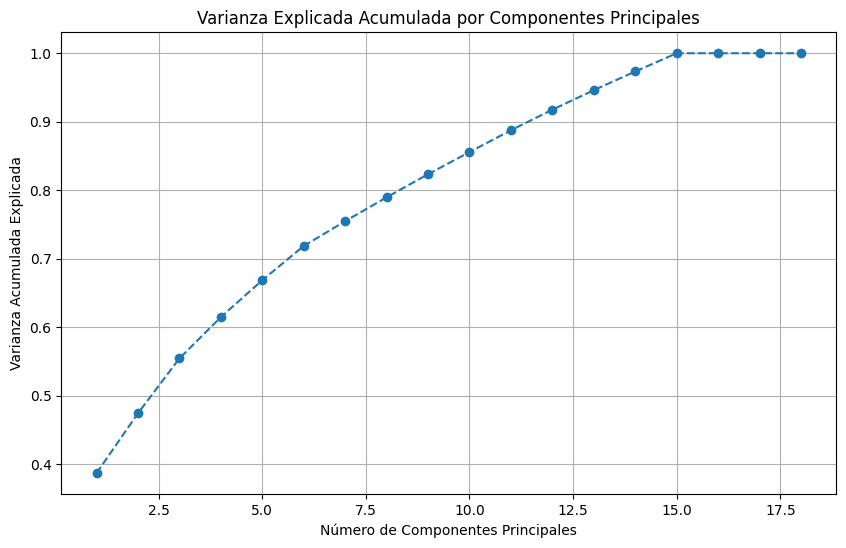

Número de componentes para retener el 95% de la varianza: 14
Primeras 5 filas de los componentes PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14
0,-7.257325,-2.754492,5.827176,4.129322,0.118975,3.070006,0.107591,0.156505,0.123478,0.146506,-0.047448,-0.247980,0.062217,0.270752
1,-7.593209,-4.807564,-3.396227,-1.446525,4.966495,1.386140,-0.316376,-0.246190,-0.096403,0.300068,-0.147208,-0.013528,0.327887,0.274686
2,-7.675821,0.257028,-2.165159,0.521957,2.994769,0.442494,0.168020,-0.364679,-0.007990,0.258854,0.015414,-0.003362,0.227139,0.191905
3,-7.570984,-4.703666,-3.261534,-2.239452,3.970454,-0.592692,-0.240243,-0.197621,0.169114,0.114607,0.223935,0.098882,0.149459,-0.058131
4,-6.652630,-2.578358,8.512324,-3.642650,4.087671,-1.460384,-0.563218,-0.329166,0.122951,0.259460,-0.208506,0.011735,-0.209599,-0.121230



Dimensiones de los componentes PCA: (1196, 14)


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos para PCA
# Excluir columnas no numéricas y la columna 'patient_id'
# 'gender' and 'blood_type' are now encoded, so we drop the original ones.
# 'most_frequent_condition' and 'most_frequent_medication' are categorical and we are excluding them for PCA.
features = patient_feature_matrix.drop(columns=['patient_id', 'most_frequent_condition_id', 'most_frequent_medication_id'])

# Escalar las características numéricas
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features.select_dtypes(include=['number']))

# Aplicar PCA
pca = PCA()
pca.fit(scaled_features)

# Varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_

# Visualizar la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio.cumsum(), marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

# Determinar el número de componentes para retener el 95% de la varianza
num_components = next(i for i, cumulative_variance in enumerate(explained_variance_ratio.cumsum()) if cumulative_variance >= 0.95) + 1
print(f"Número de componentes para retener el 95% de la varianza: {num_components}")

# Aplicar PCA con el número óptimo de componentes
pca_final = PCA(n_components=num_components)
patient_pca_components = pca_final.fit_transform(scaled_features)

patient_pca_df = pd.DataFrame(data=patient_pca_components, columns=[f'PC_{i+1}' for i in range(num_components)])

# Guardar los resultados del PCA como CSV en la carpeta data/processed
patient_pca_df.to_csv("../data/processed/healthcare_pca.csv", index=False)

print("Primeras 5 filas de los componentes PCA:")
display(patient_pca_df.head())
print(f"\nDimensiones de los componentes PCA: {patient_pca_df.shape}")

### Tabla Comparativa de Reducción de Dimensionalidad (PCA)

A continuación se presenta una tabla que resume los resultados de la reducción de dimensionalidad utilizando PCA.

In [6]:
pca_summary = pd.DataFrame({
    'Componente': range(1, len(explained_variance_ratio) + 1),
    'Varianza Explicada': explained_variance_ratio,
    'Varianza Acumulada Explicada': explained_variance_ratio.cumsum()
})

display(pca_summary.head(num_components))

print(f"La PCA con {num_components} componentes retiene el {pca_summary['Varianza Acumulada Explicada'].iloc[num_components-1]:.2%} de la varianza original.")

# Error de reconstrucción (opcional, para demostrar)
# Para calcular el error de reconstrucción, necesitamos reconstruir los datos originales
# a partir de los componentes seleccionados y luego comparar con los datos escalados originales.

reconstructed_scaled_features = pca_final.inverse_transform(patient_pca_components)

# Calculamos el error cuadrático medio (MSE) como una métrica simple de error de reconstrucción
from sklearn.metrics import mean_squared_error

reconstruction_error = mean_squared_error(scaled_features, reconstructed_scaled_features)
print(f"Error de reconstrucción (Mean Squared Error): {reconstruction_error:.4f}")

,Componente,Varianza Explicada,Varianza Acumulada Explicada
0,1,0.386968,0.386968
1,2,0.087459,0.474427
2,3,0.080026,0.554452
3,4,0.060355,0.614807
4,5,0.053850,0.668657
5,6,0.049981,0.718638
6,7,0.036228,0.754866
7,8,0.034817,0.789682
8,9,0.033726,0.823408
9,10,0.032283,0.855691


La PCA con 14 componentes retiene el 97.34% de la varianza original.
Error de reconstrucción (Mean Squared Error): 0.0266


### Reducción de Dimensionalidad con t-SNE

El t-Distributed Stochastic Neighbor Embedding (t-SNE) es una técnica de reducción de dimensionalidad no lineal que es particularmente adecuada para la visualización de conjuntos de datos de alta dimensión.

A diferencia de PCA, que intenta preservar la estructura global y la varianza, t-SNE se enfoca en preservar las relaciones de proximidad local, lo que ayuda a identificar clústeres o agrupaciones naturales en los datos.

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos los componentes de PCA ya calculados (15 componentes) para mejorar el rendimiento de t-SNE
# t-SNE es computacionalmente costoso, por lo que tomamos una muestra si el dataset es muy grande
# En este caso, procesaremos el conjunto completo tras la reducción PCA

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    max_iter=1000 # Ajustado para eficiencia
)

# Ajustar y transformar
patient_tsne_results = tsne.fit_transform(patient_pca_components)

# Create a temporary DataFrame for t-SNE results and patient_id
temp_tsne_df = pd.DataFrame(
    data=patient_tsne_results,
    columns=['tsne_1', 'tsne_2']
)
temp_tsne_df['patient_id'] = patient_feature_matrix['patient_id'].values

# Merge with demographic data
patient_tsne_df = pd.merge(
    temp_tsne_df,
    patients[['patient_id', 'Gender', 'Blood Type']],
    on='patient_id'
)

# Remove patient_id after merging if it's not needed for plotting
patient_tsne_df = patient_tsne_df.drop(columns=['patient_id'])

# Rename columns to match expected names for plotting
patient_tsne_df.rename(columns={'Gender': 'gender', 'Blood Type': 'blood_type'}, inplace=True)

display(patient_tsne_df.head())

,tsne_1,tsne_2,gender,blood_type
0,-49.786152,1.935059,0,0
1,-55.916332,-8.367163,0,2
2,-59.338615,0.144282,0,5
3,-56.507740,-8.176725,0,7
4,-51.625706,5.196686,1,0


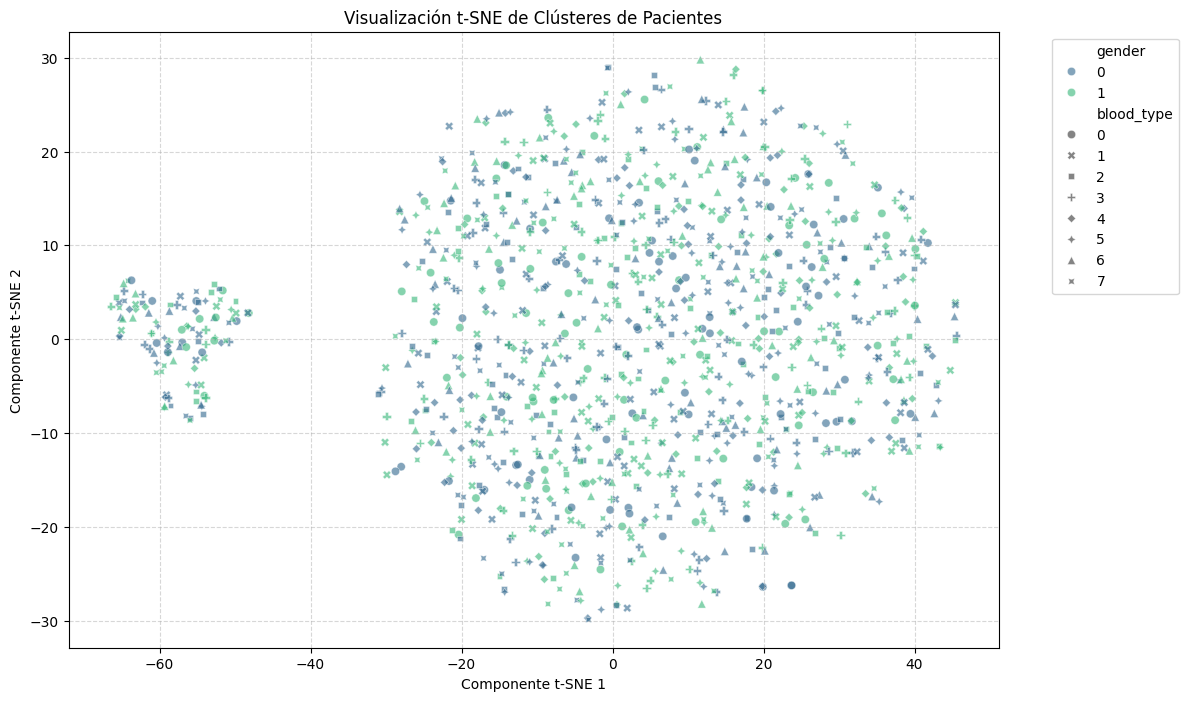

In [8]:
# Visualización de t-SNE
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='gender',
    style='blood_type',
    data=patient_tsne_df,
    palette='viridis',
    alpha=0.6
)

plt.title('Visualización t-SNE de Clústeres de Pacientes')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
import numpy as np

print(features.shape)
print(features.select_dtypes(include='number').shape)
print(np.linalg.matrix_rank(scaled_features))

(1196, 28)
(1196, 18)
15


### Visualización de Reducción de Dimensionalidad con t-SNE

Ahora aplicaremos t-Distributed Stochastic Neighbor Embedding (t-SNE) para una visualización de menor dimensionalidad. A diferencia de PCA, t-SNE es una técnica no lineal que es particularmente buena para visualizar grupos de puntos de datos, aunque no retiene la distancia global entre los grupos tan bien como PCA.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar escalado de datos
# Update column names to reflect the current state of patient_feature_matrix
features_to_scale = patient_feature_matrix.drop(columns=['patient_id', 'most_frequent_condition_id', 'most_frequent_medication_id'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale.select_dtypes(include=['number']))

In [11]:
# 2. PCA previo para reducir ruido y mejorar velocidad de t-SNE (usando 15 componentes)
pca_pre = PCA(n_components=5, random_state=42)
pca_features = pca_pre.fit_transform(scaled_features)

In [12]:
# 3. Ejecutar t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init='pca',
    learning_rate='auto'
)
patient_tsne_components = tsne.fit_transform(pca_features)

In [13]:
# 4. Preparar DataFrame para visualización
# Create a temporary DataFrame for t-SNE components and patient_id
temp_tsne_df = pd.DataFrame(data=patient_tsne_components, columns=['TSNE_1', 'TSNE_2'])
temp_tsne_df['patient_id'] = patient_feature_matrix['patient_id'].values

# Retrieve original 'Gender' and 'Blood Type' from the 'patients' DataFrame
patient_tsne_plot_df = pd.merge(
    temp_tsne_df,
    patients[['patient_id', 'Gender', 'Blood Type']],
    on='patient_id',
    how='left'
)

# Remove patient_id after merging if it's not needed for plotting
patient_tsne_plot_df = patient_tsne_plot_df.drop(columns=['patient_id'])

# Rename columns to match expected names for plotting
patient_tsne_plot_df.rename(columns={'Gender': 'gender', 'Blood Type': 'blood_type'}, inplace=True)

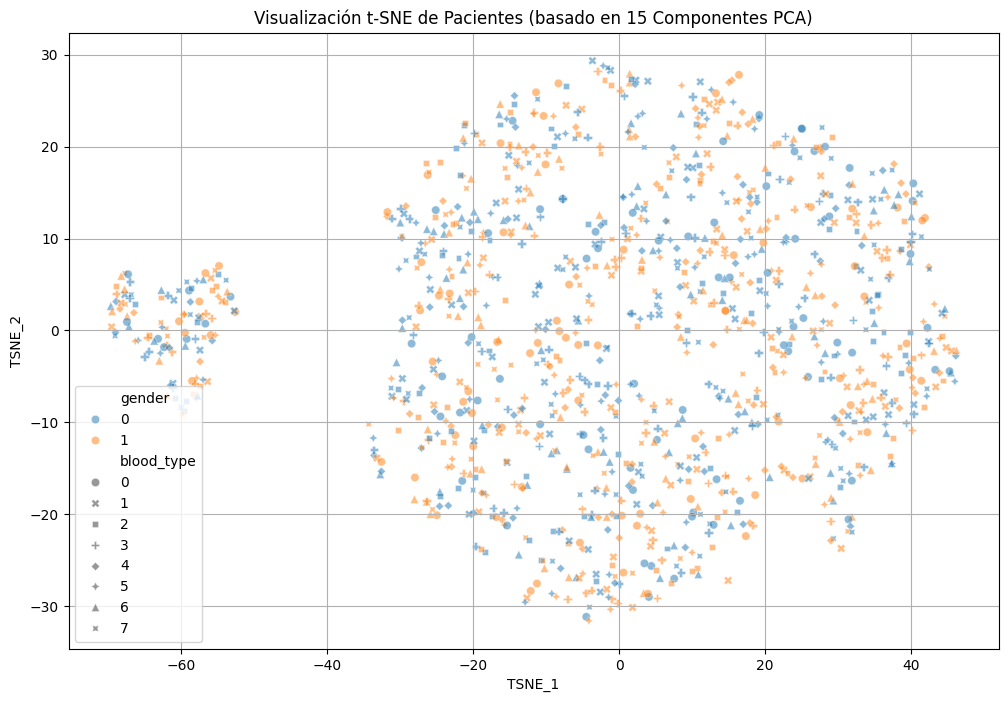

In [14]:
# 5. Graficar
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='gender', style='blood_type',
    data=patient_tsne_plot_df,
    alpha=0.5
)
plt.title('Visualización t-SNE de Pacientes (basado en 15 Componentes PCA)')
plt.grid(True)
plt.show()

### Visualizaciones Avanzadas de Análisis de Datos

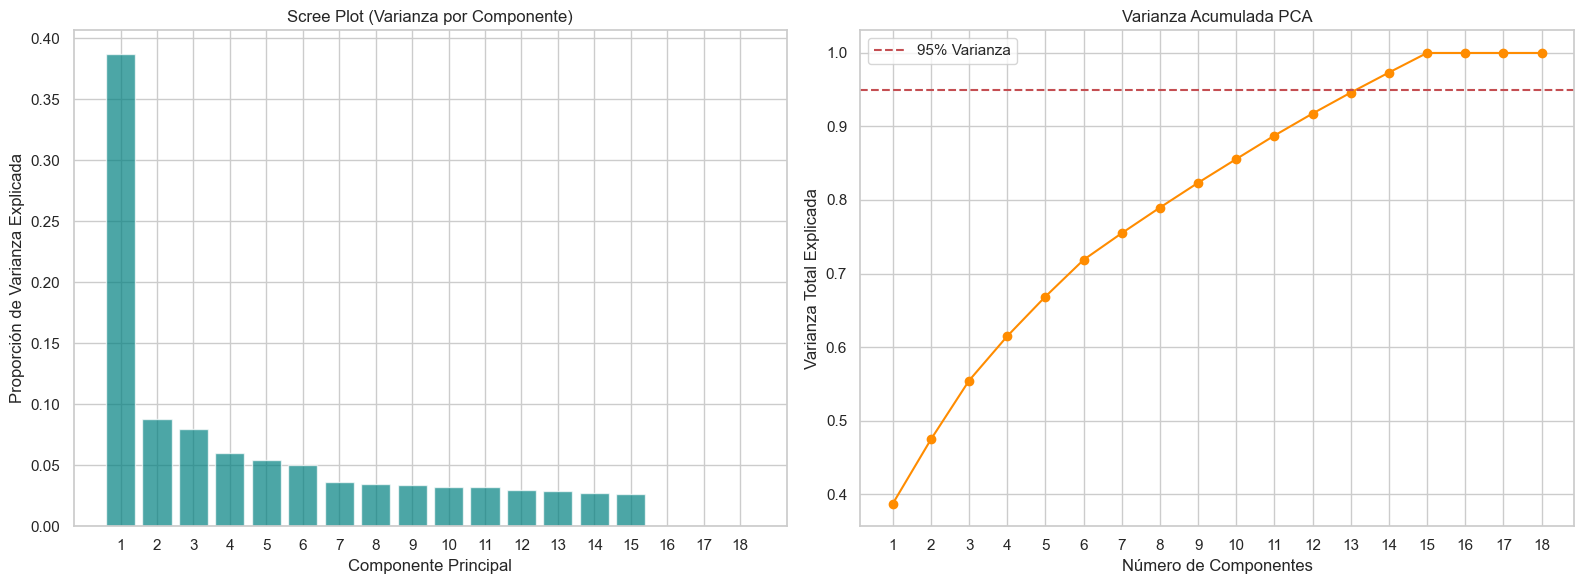

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuramos el estilo
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scree Plot (Varianza Individual)
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, color='teal', label='Varianza Individual')
ax1.set_title('Scree Plot (Varianza por Componente)')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Proporción de Varianza Explicada')
ax1.set_xticks(range(1, len(explained_variance_ratio) + 1))

# 2. Varianza Acumulada
cum_variance = np.cumsum(explained_variance_ratio)
ax2.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='-', color='darkorange')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
ax2.set_title('Varianza Acumulada PCA')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Total Explicada')
ax2.set_xticks(range(1, len(cum_variance) + 1))
ax2.legend()

plt.tight_layout()
plt.show()

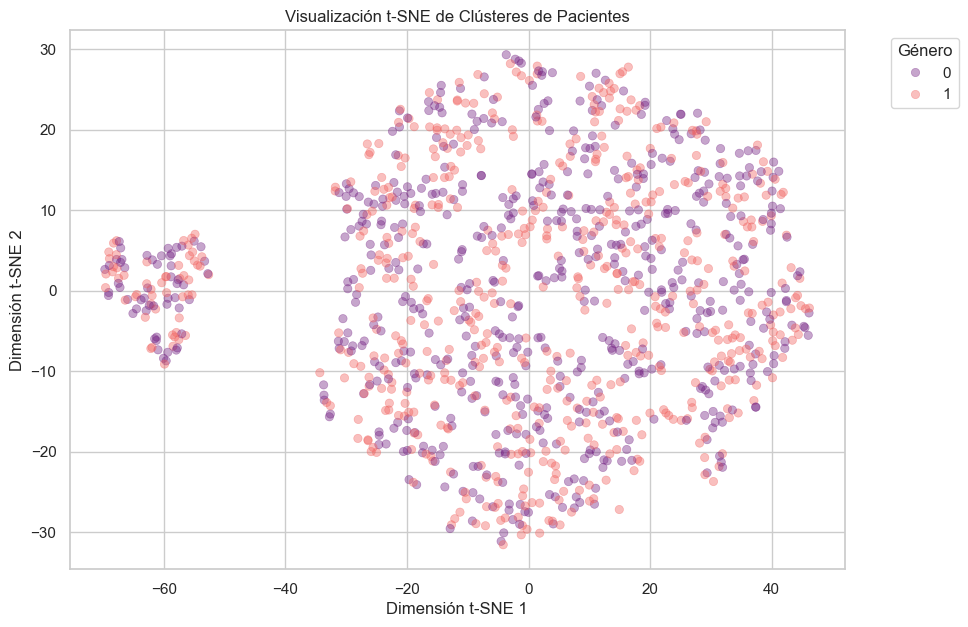

In [16]:
# 3. Scatter Plot t-SNE Optimizado
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='gender',
    data=patient_tsne_plot_df,
    palette='magma',
    alpha=0.4,
    edgecolor=None
)
plt.title('Visualización t-SNE de Clústeres de Pacientes')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

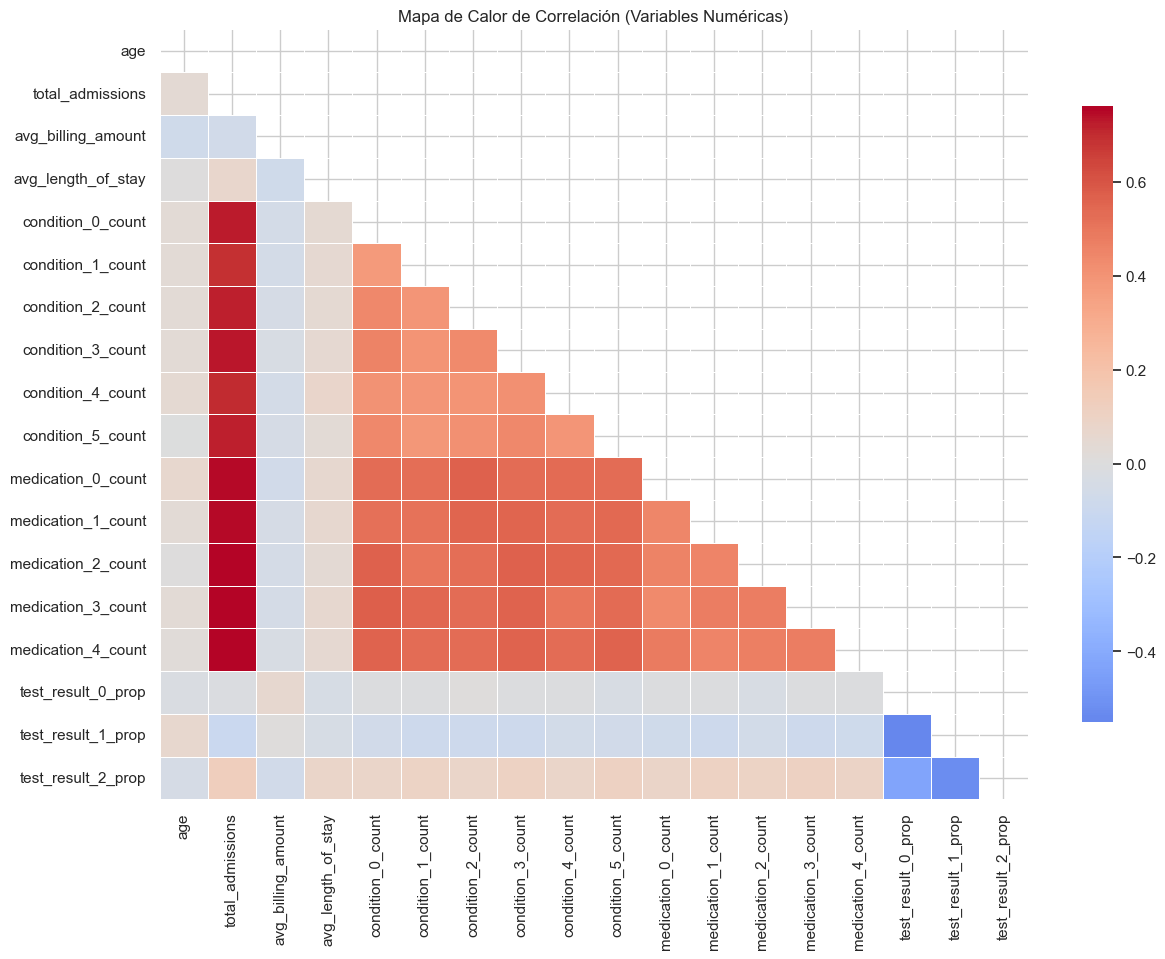

In [17]:
# 4. Heatmap de Correlación de Variables Originales
plt.figure(figsize=(14, 10))
corr_matrix = features.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Mapa de Calor de Correlación (Variables Numéricas)')
plt.show()